## 0. Computer vision libraries in PyTorch
- `torchvision` - Contains datasets, model architectures and image transformations often used for computer vision problems. 
- `torchvision.Datasets` - Gets datasets and data loading functions for computer vision here.
- `torchvision.model` - Gets pretrained computer vision models that you can laverage for ypur own problems.
- `torch.vision.transforms` - Functions for manipulating your vision data (images) to be suitable for use with an ML model.
- `torch.utils.data.Datasets` - Base dataset class for PyTorch.
- `torch.utils.data.DataLoader` - Creates a Python iterable over a dataset.


In [64]:
import torch
from torch import nn
import torchvision
from torchvision import datasets, transforms
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt


## 1. Getting a dataset
The dataset we'll be using is FashionMIST from torchvision.datasets

In [65]:
# Create the FashionMNIST training dataset object
train_data = datasets.FashionMNIST(
    root="data",  # Directory where the dataset will be stored/downloaded
    train=True,  # Load the training split (60,000 images)
    download=True,  # Download the dataset if it is not already available locally
    transform=torchvision.transforms.ToTensor(),  # Convert each image to a PyTorch tensor and scale pixel values to [0, 1]
    target_transform=None  # Do not apply any transformation to the labels
)

test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=torchvision.transforms.ToTensor(),
    target_transform=None
)



In [66]:
len(train_data), len(test_data)

(60000, 10000)

In [67]:
class_names = train_data.classes
class_names

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [68]:
class_to_idx = train_data.class_to_idx
class_to_idx

{'T-shirt/top': 0,
 'Trouser': 1,
 'Pullover': 2,
 'Dress': 3,
 'Coat': 4,
 'Sandal': 5,
 'Shirt': 6,
 'Sneaker': 7,
 'Bag': 8,
 'Ankle boot': 9}

In [69]:
train_data.targets

tensor([9, 0, 0,  ..., 3, 0, 5])

In [70]:
image, label= train_data[0]
print(f"Image shape: {image.shape} -> [color channels, height, width]")  
print(f"Image label: {class_names[label]}")

Image shape: torch.Size([1, 28, 28]) -> [color channels, height, width]
Image label: Ankle boot


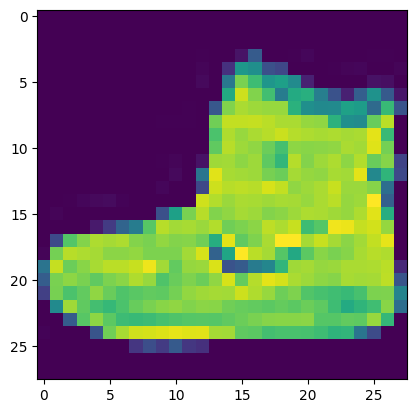

In [71]:
plt.imshow(image.squeeze());  #plt expect only height and width

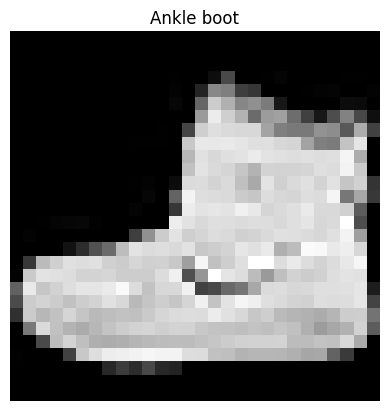

In [72]:
plt.imshow(image.squeeze(), cmap="gray")
plt.title(class_names[label])
plt.axis(False);

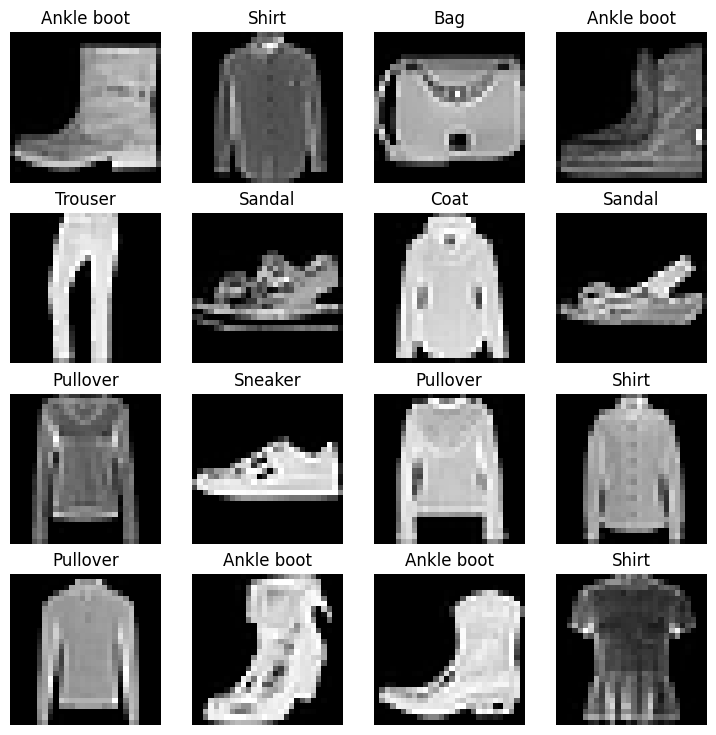

In [73]:
torch.manual_seed(42)
fig = plt.figure(figsize=(9,9))
rows, cols = 4,4
for i in range(1, rows*cols+1):
    random_idx = torch.randint(0, len(train_data), size=[1]).item()
    image, label = train_data[random_idx]
    fig.add_subplot(rows, cols, i)
    plt.imshow(image.squeeze(), cmap="gray")
    plt.title(class_names[label])
    plt.axis(False);


## 2. Prepare DataLoader

Now we've got a dataset ready to go.            
The next step is to prepare it with a `torch.utils.data.DataLoader` or `DataLoader` for short.          
The DataLoader does what you think it might do.      
It helps load data into a model.             
For training and for inference.        
It turns a large Dataset into a Python iterable of smaller chunks.        
These smaller chunks are called **batches** or **mini-batches** and can be set by the `batch_size parameter`.            
Why do this?        
Because it's more computationally efficient.            
In an ideal world you could do the forward pass and backward pass across all of your data at once.       
But once you start using really large datasets, unless you've got infinite computing power, it's easier to break them up into batches.      
It also gives your model more opportunities to improve.           
With mini-batches (small portions of the data), gradient descent is performed more often per epoch (once per mini-batch rather than once per epoch).       

**What's a good batch size?**       
**32** is a good place to start for a fair amount of problems.      
But since this is a value you can set (a hyperparameter) you can try all different kinds of values, though generally powers of 2 are used most often (e.g. 32, 64, 128, 256, 512).

In [74]:
from torch.utils.data import DataLoader

#setup the batch size hyperparameter
BATCH_SIZE = 32

#turn datasets into iterables (batches)
train_dataloader = DataLoader(dataset=train_data,
                             batch_size=BATCH_SIZE,
                             shuffle=True)
test_dataloader = DataLoader(dataset=test_data,
                            batch_size=BATCH_SIZE,
                            shuffle=False)

train_dataloader, test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x130fd1010>,
 <torch.utils.data.dataloader.DataLoader at 0x15f1e84d0>)

In [75]:
#let's check out what we've created
print(f"Length of train_dataloader: {len(train_dataloader)} batches of {BATCH_SIZE}")
print(f"Length of test_dataloader: {len(test_dataloader)} batches of {BATCH_SIZE}")

Length of train_dataloader: 1875 batches of 32
Length of test_dataloader: 313 batches of 32


In [76]:
#check out what is inside training dataloader
train_features_batch, train_label_batch = next(iter(train_dataloader)) # Get the first batch of images and labels from the training dataloader

train_features_batch.shape, train_label_batch.shape

(torch.Size([32, 1, 28, 28]), torch.Size([32]))

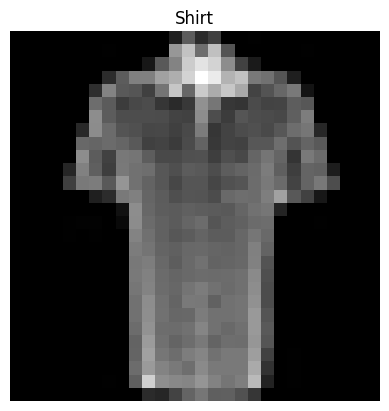

In [77]:
torch.manual_seed(42)
random_idx = torch.randint(0, len(train_features_batch), size=[1]).item()
image, label = train_features_batch[random_idx], train_label_batch[random_idx]
plt.imshow(image.squeeze(), cmap="gray")
plt.title(class_names[label])
plt.axis(False);

## Model 0 : Build a baseline model
Data loaded and prepared!         
Time to build a **baseline model** by subclassing `nn.Module`.                   
A **baseline model** is one of the simplest models you can imagine.                 
You use the baseline as a starting point and try to improve upon it with subsequent, more complicated models.                 
Our baseline will consist of two `nn.Linear()` layers.              
We've done this in a previous section but there's going to be one slight difference.              
Because we're working with image data, we're going to use a different layer to start things off.                 
And that's the `nn.Flatten()` layer.               
`nn.Flatten()` compresses the dimensions of a tensor into a single vector. 

In [78]:
# Create a flatten layer
flatten_model = nn.Flatten()# all nn modules function as a model (can do a forward pass)

X = train_features_batch[0]  # Get a single sample 
output = flatten_model(X)# Flatten the sample  (perform forward pass)

# Print out what happened
print(f"Shape before flattening: {X.shape} -> [color channels, height, width]")
print(f"Shape after flattening {output.shape} -> [color channels, height*width]")

Shape before flattening: torch.Size([1, 28, 28]) -> [color channels, height, width]
Shape after flattening torch.Size([1, 784]) -> [color channels, height*width]


In [79]:
class FashionMNISTModelV0(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()
        self.layer_stack = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features = input_shape, out_features = hidden_units),
            nn.Linear(in_features = hidden_units, out_features = output_shape)
        )

    def forward(self, x):
        return self.layer_stack(x)

torch.manual_seed(42)
model_0 = FashionMNISTModelV0(input_shape=784, hidden_units=10, output_shape=len(class_names))
model_0

FashionMNISTModelV0(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): Linear(in_features=10, out_features=10, bias=True)
  )
)

In [80]:
dummy_x = torch.rand([1,1,28,28])
model_0(dummy_x).shape

torch.Size([1, 10])

In [81]:
flatten_model(dummy_x).shape

torch.Size([1, 784])

In [82]:
dummy_x.shape

torch.Size([1, 1, 28, 28])

### 3.1 Setup loss, optimizer, evaluation metrics
- **Loss funtion:** Since we are working with-multiclass data, our loss funtion will be `nn.CrossEntropyLoss()`
- **Optimizer:** our optimizer torch.optim.SGD()
- **Evaluation Metric:** since we are working on classification problem, let's use accuracy as evaluation metric

In [83]:
from helper_functions import accuracy_fn
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params = model_0.parameters(), lr=0.1)

In [84]:
from timeit import default_timer as timer
def print_train_time(start: float, end: float):
    """prints differient between start and end time"""
    total_time = end - start
    print(f"Train time: {total_time:.3f} seconds")
    return total_time

In [85]:
start_time = timer()
#some code...
end_time = timer()
print_train_time(start=start_time, end=end_time)

Train time: 0.000 seconds


6.542002665810287e-06

### 3.3 Creating a training loop and training a model on batches of data
Let's now create a training loop and a testing loop to train and evaluate our model.

We'll be using the same steps as the previous notebook(s), though since our data is now in batch form, we'll add another loop to loop through our data batches.

Our data batches are contained within our `DataLoaders`, `train_dataloader` and `test_dataloader` for the training and test data splits respectively.

A batch is `BATCH_SIZE` samples of X (features) and y (labels), since we're using BATCH_SIZE=32, our batches have 32 samples of images and targets.

**And since we're computing on batches of data, our loss and evaluation metrics will be calculated per batch rather than across the whole dataset.**

This means we'll have to divide our loss and accuracy values by the number of batches in each dataset's respective dataloader.

Let's step through it:

- Loop through epochs.
- Loop through training batches, perform training steps, calculate the train loss per batch.
- Loop through testing batches, perform testing steps, calculate the test loss per batch.
- Print out what's happening.
- Time it all (for fun).

In [104]:
# Import tqdm for progress bar
from tqdm.auto import tqdm

# Set the number of epochs (we'll keep this small for faster training times)
epochs = 3
torch.manual_seed(42)
train_time_start = timer()

# Create training and testing loop
for epoch in tqdm(range(epochs)):
    print(f"Epoch: {epoch}\n-------")

    ### Training
    train_loss = 0
    train_acc = 0
    
    # Add a loop to loop through training batches
    for batch, (X,y) in enumerate(train_dataloader):
        model_0.train()

        y_pred = model_0(X)    # 1. Forward pass

        # 2. Calculate loss (per batch)
        loss = loss_fn(y_pred, y)
        acc = accuracy_fn(y_true=y, y_pred=y_pred.argmax(dim=1))

        optimizer.zero_grad()   # 3. Optimizer zero grad
        loss.backward()         # 4. Loss backward
        optimizer.step()        # 5. Optimizer step

        train_loss += loss  # accumulatively add up the loss per epoch 
        train_acc += acc

        # Print out how many samples have been seen
        if batch % 400 == 0:
            print(f"Looked at {batch * len(X)}/{len(train_dataloader.dataset)} samples")

    # Divide total train loss by length of train dataloader (average loss per batch per epoch)
    train_loss /= len(train_dataloader)
    train_acc /= len(train_dataloader)

    ### Testing
    # Setup variables for accumulatively adding up loss and accuracy 
    test_loss, test_acc = 0,0
    model_0.eval()
    with torch.inference_mode():
        for X,y in test_dataloader:
            test_pred = model_0(X)   # 1. Forward pass
            test_loss += loss_fn(test_pred, y)   # 2. Calculate loss (accumulatively)
            test_acc += accuracy_fn(y_true=y, y_pred=test_pred.argmax(dim=1))   # 3. Calculate accuracy (preds need to be same as y_true)

        # Calculations on test metrics need to happen inside torch.inference_mode()
        test_loss /= len(test_dataloader)      # Divide total test loss by length of test dataloader (per batch)
        test_acc /= len(test_dataloader)       # Divide total accuracy by length of test dataloader (per batch)

    ## Print out what's happening
    print(f"\nTrain loss: {train_loss:.5f} | Test loss: {test_loss:.5f}, Train acc: {train_acc:.2f} | Test acc: {test_acc:.2f}%\n")

# Calculate training time
train_time_end = timer()
total_train_time_model_0 = print_train_time(start=train_time_start, end=train_time_end)
    

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
-------
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples

Train loss: 0.43026 | Test loss: 0.47664, Train acc: 84.94 | Test acc: 83.43%

Epoch: 1
-------
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples

Train loss: 0.43026 | Test loss: 0.47664, Train acc: 84.94 | Test acc: 83.43%

Epoch: 2
-------
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples

Train loss: 0.43026 | Test loss: 0.47664, Train acc: 84.94 | Test acc: 83.43%

Train time: 3.738 seconds


## 4. Make predictions and get Model 0 results

Since we're going to be building a few models, it's a good idea to write some code to evaluate them all in similar ways.

Namely, let's create a function that takes in a trained model, a DataLoader, a loss function and an accuracy function.

The function will use the model to make predictions on the data in the DataLoader and then we can evaluate those predictions using the loss function and accuracy function.

In [87]:
torch.manual_seed(42)
def eval_model(model: nn.Module,
              data_loader: torch.utils.data.DataLoader,
              loss_fn: nn.Module,
              accuracy_fn):
    """Returns a dictionary containing the results of model predicting on data_loader.

    Args:
        model (torch.nn.Module): A PyTorch model capable of making predictions on data_loader.
        data_loader (torch.utils.data.DataLoader): The target dataset to predict on.
        loss_fn (torch.nn.Module): The loss function of model.
        accuracy_fn: An accuracy function to compare the models predictions to the truth labels.

    Returns:
        (dict): Results of model making predictions on data_loader.
    """
    loss, acc= 0,0
    model.eval()
    with torch.inference_mode():
        for X,y in data_loader:
            y_pred = model(X)    # Make predictions with the model

            # Accumulate the loss and accuracy values per batch
            loss += loss_fn(y_pred, y)
            acc += accuracy_fn(y_true = y, y_pred=y_pred.argmax(dim=1))  # For accuracy, need the prediction labels (logits -> pred_prob -> pred_labels)

        # Scale loss and acc to find the average loss/acc per batch
        loss /= len(data_loader)
        acc /= len(data_loader)

    return {"model_name": model.__class__.__name__,   # only works when model was created with a class
            "model_loss": loss.item(),
            "model_acc": acc}

# Calculate model 0 results on test dataset
model_0_results = eval_model(model=model_0, data_loader=test_dataloader, loss_fn=loss_fn, accuracy_fn=accuracy_fn)
model_0_results

{'model_name': 'FashionMNISTModelV0',
 'model_loss': 0.47663894295692444,
 'model_acc': 83.42651757188499}

## 6. Model 1: Building a better model with non-linearity

In [88]:
# Create a model with non-linear and linear layers
class FashionMNISTModelV1(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()
        self.layer_stack = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=input_shape, out_features=hidden_units),
            nn.ReLU(),
            nn.Linear(in_features=hidden_units, out_features=output_shape),
            nn.ReLU()
        )

    def forward(self, x):
        return self.layer_stack(x)

model_1 = FashionMNISTModelV1(input_shape=784, hidden_units=10, output_shape=len(class_names))
model_1

FashionMNISTModelV1(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): ReLU()
    (3): Linear(in_features=10, out_features=10, bias=True)
    (4): ReLU()
  )
)

### 6.1 Setup loss, optimizer and evaluation metrics

In [89]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_1.parameters(), lr=0.1)

### 6.2 Functionizing training and test loops

In [90]:
def train_step(model: nn.Module,
               data_loader: torch.utils.data.DataLoader,
              loss_fn: nn.Module,
               optimizer: torch.optim.Optimizer,
              accuracy_fn):

    train_loss = 0
    train_acc = 0
    
    # Add a loop to loop through training batches
    for batch, (X,y) in enumerate(data_loader):
        model.train()

        y_pred = model(X)    # 1. Forward pass

        # 2. Calculate loss (per batch)
        loss = loss_fn(y_pred, y)
        acc = accuracy_fn(y_true=y, y_pred=y_pred.argmax(dim=1))

        optimizer.zero_grad()   # 3. Optimizer zero grad
        loss.backward()         # 4. Loss backward
        optimizer.step()        # 5. Optimizer step

        train_loss += loss  # accumulatively add up the loss per epoch 
        train_acc += acc
        
    # Divide total train loss by length of train dataloader (average loss per batch per epoch)
    train_loss /= len(data_loader)
    train_acc /= len(data_loader)
    print(f"Train Loss: {train_loss:.5f} | Train Accuracy: {train_acc:.2f}%\n")

def test_step(model: nn.Module,
             data_loader: torch.utils.data.DataLoader,
             loss_fn: nn.Module,
             optimizer: torch.optim.Optimizer,
             accuracy_fn):
    
    test_loss, test_acc = 0,0
    model.eval()
    with torch.inference_mode():
        for X,y in data_loader:
            test_pred = model(X)   # 1. Forward pass
            test_loss += loss_fn(test_pred, y)   # 2. Calculate loss (accumulatively)
            test_acc += accuracy_fn(y_true=y, y_pred=test_pred.argmax(dim=1))   # 3. Calculate accuracy (preds need to be same as y_true)

        # Calculations on test metrics need to happen inside torch.inference_mode()
        test_loss /= len(data_loader)      # Divide total test loss by length of test dataloader (per batch)
        test_acc /= len(data_loader)       # Divide total accuracy by length of test dataloader (per batch)
        print(f"Test Loss: {test_loss:.5f} | Test Accuracy: {test_acc:.2f}%")

In [107]:
epochs = 3
torch.manual_seed(42)
train_time_start = timer()

# Create training and testing loop
for epoch in tqdm(range(epochs)):
    print(f"Epoch: {epoch}\n-------")
    train_step(model=model_1,
               data_loader=train_dataloader,
               loss_fn=loss_fn,
               optimizer=optimizer,
               accuracy_fn=accuracy_fn)

    test_step(model=model_1,
             data_loader=test_dataloader,
             loss_fn=loss_fn,
             optimizer=optimizer,
             accuracy_fn=accuracy_fn)

# Calculate training time
train_time_end = timer()
total_train_time_model_1 = print_train_time(start=train_time_start, end=train_time_end)

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
-------
Train Loss: 0.64265 | Train Accuracy: 76.16%

Test Loss: 0.69170 | Test Accuracy: 74.81%
Epoch: 1
-------
Train Loss: 0.64265 | Train Accuracy: 76.16%

Test Loss: 0.69170 | Test Accuracy: 74.81%
Epoch: 2
-------
Train Loss: 0.64265 | Train Accuracy: 76.16%

Test Loss: 0.69170 | Test Accuracy: 74.81%
Train time: 3.408 seconds


In [92]:
model_1_results = eval_model(model= model_1,
                            data_loader= test_dataloader,
                            loss_fn= loss_fn,
                            accuracy_fn=accuracy_fn)
model_1_results

{'model_name': 'FashionMNISTModelV1',
 'model_loss': 0.6917039752006531,
 'model_acc': 74.810303514377}

## 7. Model 2: Building a Convolutional Neural Network (CNN)
It follows the typical structure of a convolutional neural network:

`Input layer -> [Convolutional layer -> activation layer -> pooling layer] -> Output layer`

Where the contents of `[Convolutional layer -> activation layer -> pooling layer]` can be upscaled and repeated multiple times, depending on requirements.

The CNN model we're going to be using is known as TinyVGG from the **CNN Explainer website**.

In [93]:
class FashionMNISTModelV2(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()
        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape,
                     out_channels=hidden_units,
                     kernel_size=3,
                     stride=1,
                     padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units,
                     out_channels=hidden_units,
                     kernel_size=3,
                     stride=1,
                     padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(in_channels=hidden_units,
                     out_channels=hidden_units,
                     kernel_size=3,
                     stride=1,
                     padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units,
                     out_channels=hidden_units,
                     kernel_size=3,
                     stride=1,
                     padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=hidden_units*7*7,
                     out_features=output_shape)
        )

    def forward(self, x):
        return self.classifier(self.conv_block_2(self.conv_block_1(x)))

model_2 = FashionMNISTModelV2(input_shape=1, hidden_units=10, output_shape=len(class_names))
model_2
        

FashionMNISTModelV2(
  (conv_block_1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)

### 7.1 Stepping through nn.Conv2d()

We could start using our model above and see what happens but let's first step through the two new layers we've added:

`nn.Conv2d()`, also known as a convolutional layer.         
`nn.MaxPool2d()`, also known as a max pooling layer.      
**Question: What does the "2d" in nn.Conv2d() stand for?**           

The 2d is for 2-dimensional data. As in, our images have two dimensions: height and width. Yes, there's color channel dimension but each of the color channel dimensions have two dimensions too: height and width.               

For other dimensional data (such as 1D for text or 3D for 3D objects) there's also nn.Conv1d() and nn.Conv3d().        

To test the layers out, let's create some toy data just like the data used on CNN Explainer.        

In [94]:
torch.manual_seed(42)
images = torch.randn(size=(32,3,64,64))
test_image = images[0]
test_image.shape

torch.Size([3, 64, 64])

Let's create an example `nn.Conv2d()`  with various parameters:

`in_channels` (int) - Number of channels in the input image.            
`out_channels`  (int) - Number of channels produced by the convolution.           
`kernel_size`  (int or tuple) - Size of the convolving kernel/filter.           
`stride`  (int or tuple, optional) - How big of a step the convolving kernel takes at a time. Default: 1.         
`padding`  (int, tuple, str) - Padding added to all four sides of input. Default: 0.

In [95]:
torch.manual_seed(42)

# Create a convolutional layer with same dimensions as TinyVGG 
# (try changing any of the parameters and see what happens)
conv_layer = nn.Conv2d(in_channels=3,
                      out_channels=10,
                      kernel_size=3,
                      stride=1,
                      padding=0)   # also try using "valid" or "same" here 

# Pass the data through the convolutional layer
conv_layer(test_image).shape

torch.Size([10, 62, 62])

### 7.2 Stepping through nn.MaxPool2d()

Now let's check out what happens when we move data through `nn.MaxPool2d()`.

In [96]:
max_pool_layer = nn.MaxPool2d(kernel_size=2)
test_image.shape, max_pool_layer(test_image).shape

(torch.Size([3, 64, 64]), torch.Size([3, 32, 32]))

### 7.3 Setup a loss function and optimizer for model_2

In [97]:
from helper_functions import accuracy_fn
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_2.parameters(),lr=0.1)

In [102]:
torch.manual_seed(42)

#measure time
train_time_start_model_2 = timer()

epochs=3
for epoch in tqdm(range(epochs)):
    print(f"Epoch: {epoch}\n-------")
    train_step(model=model_2,
               data_loader=train_dataloader,
               loss_fn=loss_fn,
               optimizer=optimizer,
               accuracy_fn=accuracy_fn)

    test_step(model=model_2,
             data_loader=test_dataloader,
             loss_fn=loss_fn,
             optimizer=optimizer,
             accuracy_fn=accuracy_fn)

train_time_end_model_2 = timer()
total_train_time_model_2 = print_train_time(start=train_time_start_model_2, end=train_time_end_model_2)

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
-------
Train Loss: 0.29233 | Train Accuracy: 89.38%

Test Loss: 0.29964 | Test Accuracy: 89.45%
Epoch: 1
-------
Train Loss: 0.27820 | Train Accuracy: 89.79%

Test Loss: 0.30548 | Test Accuracy: 88.92%
Epoch: 2
-------
Train Loss: 0.26724 | Train Accuracy: 90.29%

Test Loss: 0.29596 | Test Accuracy: 89.18%
Train time: 42.329 seconds


In [99]:
model_2_results = eval_model(model= model_2,
                            data_loader= test_dataloader,
                            loss_fn= loss_fn,
                            accuracy_fn=accuracy_fn)
model_2_results

{'model_name': 'FashionMNISTModelV2',
 'model_loss': 0.31252896785736084,
 'model_acc': 88.67811501597444}

In [101]:
import pandas as pd
compare_results = pd.DataFrame([model_0_results,
                              model_1_results,
                              model_2_results])
compare_results

,model_name,model_loss,model_acc
0,FashionMNISTModelV0,0.476639,83.426518
1,FashionMNISTModelV1,0.691704,74.810304
2,FashionMNISTModelV2,0.312529,88.678115


In [108]:
compare_results["total_time"]= [total_train_time_model_0,
                               total_train_time_model_1,
                               total_train_time_model_2]
compare_results

,model_name,model_loss,model_acc,total_time
0,FashionMNISTModelV0,0.476639,83.426518,3.738217
1,FashionMNISTModelV1,0.691704,74.810304,3.408372
2,FashionMNISTModelV2,0.312529,88.678115,42.329215


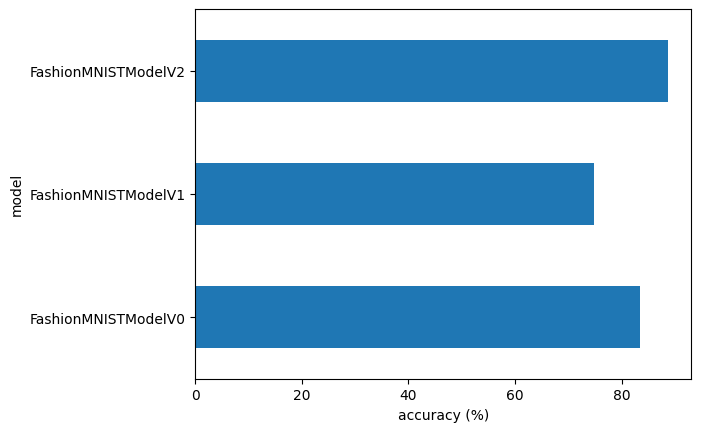

In [109]:
# Visualize our model results
compare_results.set_index("model_name")["model_acc"].plot(kind="barh")
plt.xlabel("accuracy (%)")
plt.ylabel("model");

## 9. Make and evaluate random predictions with best model

In [112]:
def make_predictions(model: nn.Module,
                    data: list):
    pred_probs = []
    model.eval()
    with torch.inference_mode():
        for sample in data:
            sample = torch.unsqueeze(sample, dim=0)                   # Prepare sample
            pred_logit = model(sample)                                # Forward pass (model outputs raw logit)

            # Get prediction probability (logit -> prediction probability)
            # note: perform softmax on the "logits" dimension, not "batch" dimension (in this case we have a batch size of 1, so can perform on dim=0)
            pred_prob = torch.softmax(pred_logit.squeeze(), dim=0)
            pred_probs.append(pred_prob)

    return torch.stack(pred_probs)   # Stack the pred_probs to turn list into a tensor
            

In [128]:
import random
test_samples = []
test_labels = []
for sample, label in random.sample(list(test_data), k=9):
    test_samples.append(sample)
    test_labels.append(label)

print(f"Test sample image shape: {test_samples[0].shape}\n Test sample label: {test_labels[0]} ({class_names[test_labels[0]]})")

Test sample image shape: torch.Size([1, 28, 28])
 Test sample label: 8 (Bag)


And now we can use our `make_predictions()`  function to predict on `test_samples`.

In [129]:
pred_probs = make_predictions(model = model_2,
                             data = test_samples)
pred_probs

tensor([[2.0169e-06, 8.3200e-07, 4.5861e-07, 1.8446e-06, 3.0967e-08, 1.7234e-07,
         2.9702e-07, 2.7685e-08, 9.9999e-01, 4.7790e-08],
        [1.3067e-02, 5.7295e-07, 7.7198e-02, 4.0458e-05, 5.4096e-02, 3.1311e-06,
         8.5556e-01, 1.8083e-07, 2.6199e-05, 6.7906e-06],
        [6.0239e-06, 9.9996e-01, 1.6953e-07, 1.8109e-05, 1.7575e-05, 1.1954e-06,
         1.7166e-07, 1.5797e-07, 7.3374e-08, 4.3543e-08],
        [2.9019e-05, 2.4169e-08, 6.6917e-06, 2.3771e-06, 3.1143e-05, 1.2288e-04,
         6.1765e-06, 7.1376e-07, 9.9980e-01, 4.4045e-09],
        [7.3780e-07, 9.9999e-01, 1.8265e-08, 4.6812e-06, 9.8707e-07, 2.4588e-07,
         3.0401e-08, 1.4245e-08, 1.0372e-08, 1.1456e-08],
        [8.1108e-01, 8.0120e-05, 5.3565e-04, 4.0533e-03, 5.7452e-06, 2.4026e-04,
         1.8379e-01, 3.0339e-05, 1.5743e-04, 2.6995e-05],
        [7.3777e-06, 1.6670e-09, 1.1346e-06, 8.8893e-08, 4.3280e-08, 1.4026e-03,
         9.6858e-06, 8.8588e-04, 1.0338e-03, 9.9666e-01],
        [5.7169e-04, 2.2322

In [130]:
pred_classes = pred_probs.argmax(dim=1)
pred_classes, test_labels

(tensor([8, 6, 1, 8, 1, 0, 9, 6, 0]), [8, 6, 1, 8, 1, 0, 9, 6, 0])

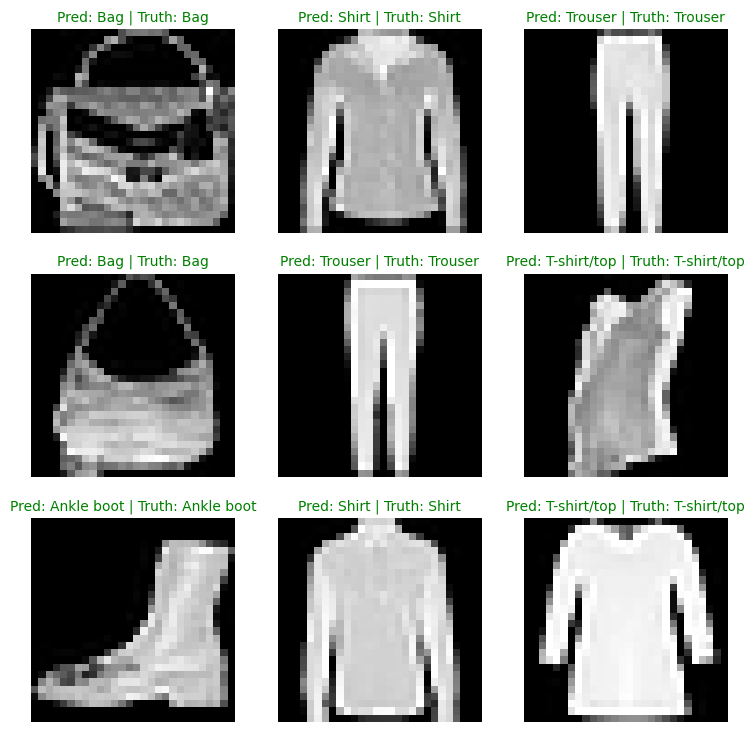

In [132]:
# Plot predictions
plt.figure(figsize=(9,9))
nrows = 3
ncols = 3
for i, sample in enumerate(test_samples):
    plt.subplot(nrows, ncols, i+1)                # Create a subplot
    plt.imshow(sample.squeeze(), cmap="gray")     # Plot the target image
    
    pred_label = class_names[pred_classes[i]]     # Find the prediction label (in text form, e.g. "Sandal")
    truth_label = class_names[test_labels[i]]     # Get the truth label (in text form, e.g. "T-shirt")
    title_text = f"Pred: {pred_label} | Truth: {truth_label}"     # Create the title text of the plot

    # Check for equality and change title colour accordingly
    if(pred_label == truth_label):
        plt.title(title_text, size=10, c="g")       # green text if correct
    else:
        plt.title(title_text, size=10, c="r")       # red text if wrong
    plt.axis(False)